In [36]:
%matplotlib ipympl

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from manifolks.decoder import Decoder, ManifoldPerturbation
from manifolks.rnn import RNN
from manifolks.task import (
  create_stim_center_reach_out,
  create_target_trajectories_center_reach_out,
  cost,
)
from manifolks.plot_utils import plot_explained_variance

In [2]:
# Output Directory
OUT_DIR = Path.cwd().parents[1] / "data"
OUT_DIR.mkdir(exist_ok=True, parents=True)

In [3]:
# Simulation Parameters
RANDOM_SEED = 2
DT = 0.01 # intergration time step
T = 2 # total simulation time
TIME = np.arange(0, T, DT) # time vector
T_STEPS = len(TIME) # number of time steps
TARGETS = 6 # number of radial directions
TARGET_MAX_RADIUS = 0.2 # max reachout distance
PULSE_LENGTH = int(TARGET_MAX_RADIUS / DT) 
N_COMPONENTS = 4  # reduced dimensionality for decoding

In [4]:
# Network Parameters
N = 800 # number of neurons
G = 1.5  # recurrent coupling strength
P = 0.2  # connection probability
TAU = 0.01 # time constant for synaptic dynamics

In [5]:
# Training Parameters
N_TRIALS_TRAIN = 80  # number of trials for initial training
N_TRIALS_RELEARN = 80  # number of trials for relearning
N_TRIALS_BCI_MANIFOLD = 50  # number of trials for BCI manifold computation
LEARNING_RATE = 20. # learning rate for all network trainings

In [6]:
np.random.seed(RANDOM_SEED)

### Create Stimuli (Target Cues)

(6, 200, 6)

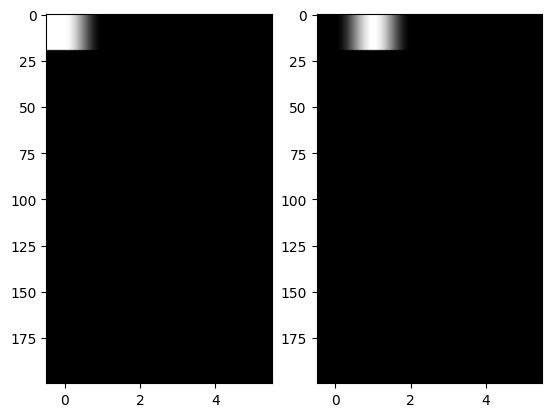

In [7]:
stim = create_stim_center_reach_out(T_STEPS, PULSE_LENGTH, TARGETS)
display(stim.shape)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(stim[0], aspect='auto', cmap='gray')
axes[1].imshow(stim[1], aspect='auto', cmap='gray')

### Create linear reach out trajectories towards the target

(6, 200, 2)

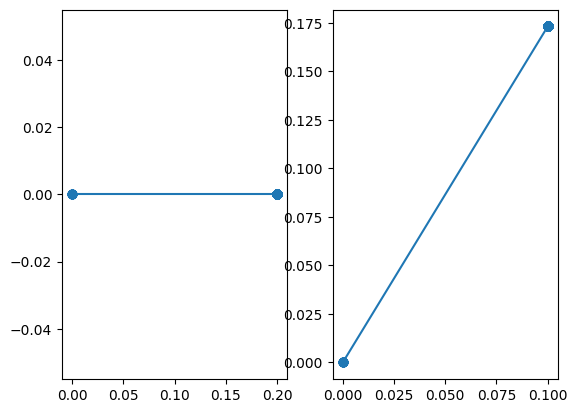

In [8]:
target_traj = create_target_trajectories_center_reach_out(
    T_STEPS, PULSE_LENGTH, TARGETS, TARGET_MAX_RADIUS)
display(target_traj.shape)
fig, axes = plt.subplots(1, 2)
axes[0].plot(target_traj[0][:, 0], target_traj[0][:, 1], "o-")
axes[1].plot(target_traj[1][:, 0], target_traj[1][:, 1], "o-")

### Initialize Neural Network (RNN)

Text(0, 0.5, 'Stimuli (I)')

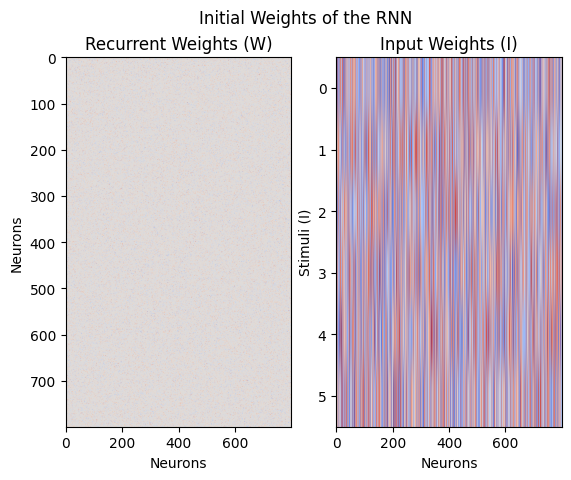

In [ ]:
network = RNN(N, g=G, p=P, N_in=TARGETS, dt=DT, tau=TAU)
network.save(OUT_DIR / "rnn")
w0 = network.W.copy()  # randomly initialized weights

# plot the initial weights
fig, axs = plt.subplots(1, 2)
fig.suptitle("Initial Weights of the RNN")

axs[0].imshow(w0, cmap='coolwarm', vmin=-1, vmax=1, aspect="auto")
axs[0].set_title("Recurrent Weights (W)")
axs[0].set_xlabel("Neurons")
axs[0].set_ylabel("Neurons")

axs[1].imshow(network.W_in.T, cmap='coolwarm', vmin=-1, vmax=1, aspect="auto")
axs[1].set_title("Input Weights (I)")
axs[1].set_xlabel("Neurons")
axs[1].set_ylabel("Stimuli (I)")

In [18]:
print(w0)

[[-0.         -0.         -0.         ...  0.         -0.
  -0.        ]
 [ 0.         -0.          0.         ... -0.01402885 -0.
  -0.        ]
 [ 0.          0.         -0.         ... -0.          0.
  -0.12797378]
 ...
 [ 0.          0.04266822  0.         ... -0.         -0.
  -0.        ]
 [ 0.00034239 -0.          0.         ... -0.         -0.
  -0.        ]
 [-0.         -0.         -0.         ... -0.31348991 -0.
   0.        ]]


### Initialize Random Decoder (BCI)

Text(0.5, 0, 'Readout Weights')

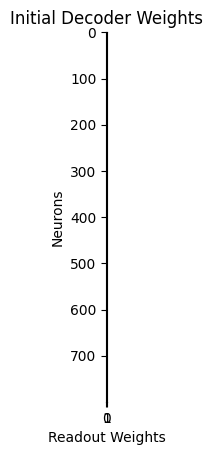

In [12]:
decoder = Decoder(N=N, N_out=2, reduced_dim=N_COMPONENTS)
decoder.set_initial_weights(TARGET_MAX_RADIUS)
bci_w0 = decoder.W.copy()  # initial decoder weights
fig, ax = plt.subplots(1, 1)
ax.set_title("Initial Decoder Weights")
ax.imshow(bci_w0.T, cmap='coolwarm', vmin=-0.1, vmax=0.1)
ax.set_ylabel("Neurons")
ax.set_xlabel("Readout Weights")

### RNN learns to reach out.

Text(0, 0.5, 'Loss')

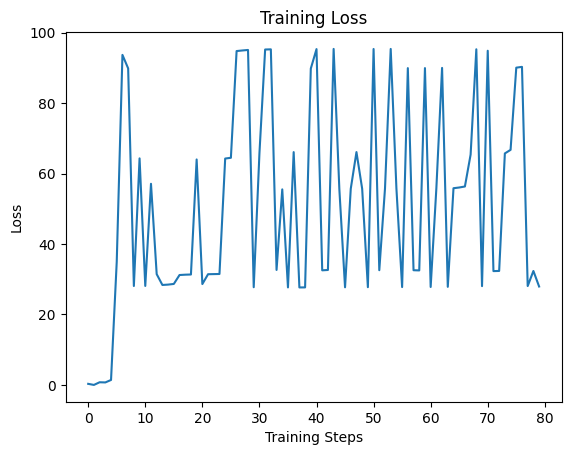

In [11]:
learn_loss = network.train(N_TRIALS_TRAIN, stim, PULSE_LENGTH, decoder, target_traj, lr=LEARNING_RATE)
fig, ax = plt.subplots(1, 1)
ax.set_title("Training Loss")
ax.plot(learn_loss, label="Training Loss")
ax.set_xlabel("Training Steps")
ax.set_ylabel("Loss")

Text(0.5, 1.0, 'Initial Weights')

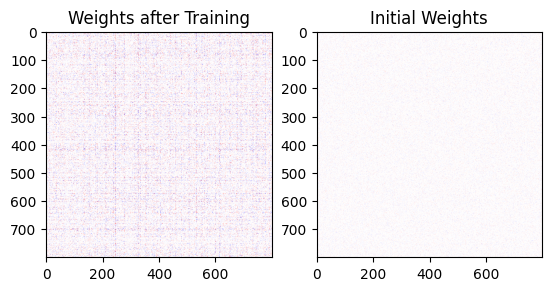

In [12]:
w1 = network.W.copy()  # weights after initial training
fig, axs = plt.subplots(1, 2)
axs[0].imshow(w1, cmap='bwr', vmin=-1, vmax=1)
axs[0].set_title("Weights after Training")
axs[1].imshow(w0, cmap='bwr', vmin=-1, vmax=1)
axs[1].set_title("Initial Weights")

#### Compute Manifold

Number of components needed for 0.8 % explained - 1


AttributeError: module 'matplotlib.pyplot' has no attribute 'pltvline'

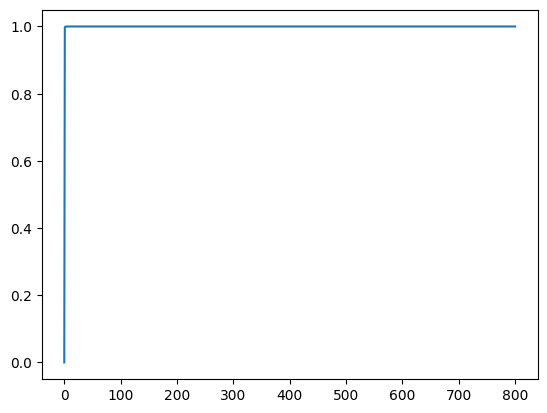

In [16]:
manifold_dict = network.compute_manifold(N_TRIALS_BCI_MANIFOLD, stim, PULSE_LENGTH)
plot_explained_variance(manifold_dict["evals"], target_variance=0.8)
manifold_dict.keys()

Text(0.5, 0.92, 'Activity of Neurons Over Trials')

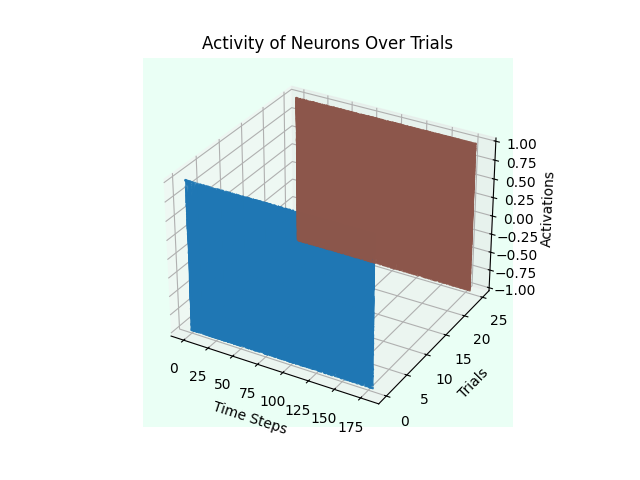

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#eafff5')
activity = manifold_dict["activity"]

cmap = plt.get_cmap('tab10', 50)

# plot activity for particular trials.
manifold_dict["trial_order"]

for trial_idx in range(0, 50, 25):  # fewer trials to keep it readable
  for neuron_idx in range(N):
    z = neuron_idx
    x = np.arange(activity.shape[1])
    y = activity[trial_idx, :, neuron_idx]
    ax.plot(x, y, zs=trial_idx, zdir='y', alpha=0.8, color=cmap(trial_idx))
ax.set_xlabel('Time Steps')
ax.set_ylabel('Trials')
ax.set_zlabel('Activations')
ax.set_title('Activity of Neurons Over Trials')

### Decoder regresses on neural activity

In [ ]:
bci_loss = decoder.train(
    manifold_dict["xi"][:,:,:N_COMPONENTS], # but Feulner uses ndims of projected data (xi[:ndims])!?
    target_traj[:, PULSE_LENGTH:,:],
    manifold_dict["trial_order"]
)

Decoder trained with MSE: 0.0193


Text(0.5, 0, 'Readout Weights')

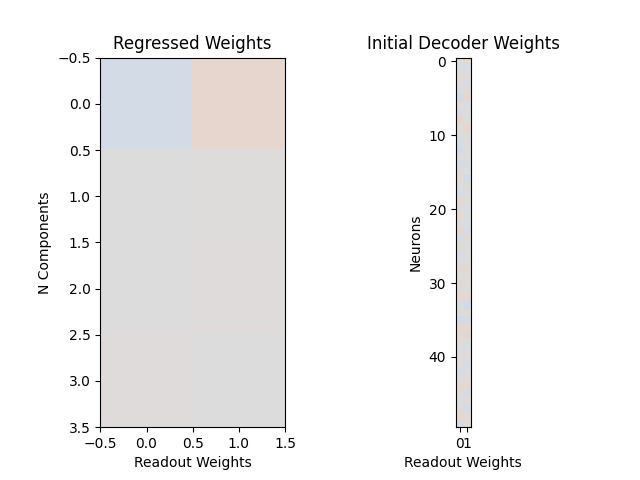

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].set_title("Regressed Weights")
axs[0].imshow(decoder.W.T, cmap='coolwarm', vmin=-0.1, vmax=0.1)
axs[0].set_ylabel("N Components")
axs[0].set_xlabel("Readout Weights")

axs[1].set_title("Initial Decoder Weights")
axs[1].imshow(bci_w0.T, cmap='coolwarm', vmin=-0.1, vmax=0.1)
axs[1].set_ylabel("Neurons")
axs[1].set_xlabel("Readout Weights")

Original Cost: 0.9714


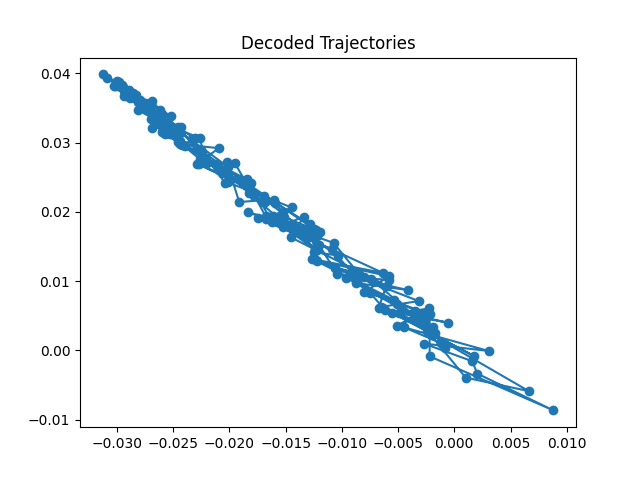

In [ ]:
og_result = decoder.decode(manifold_dict)
og_cost = cost(og_result, target_traj[:, PULSE_LENGTH:, :], manifold_dict["trial_order"])
print(f"Original Cost: {og_cost:.4f}")
fig, ax = plt.subplots(1, 1)
ax.set_title("Decoded Trajectories")
trial_idx = 40
ax.plot(og_result[trial_idx,:, 0], og_result[trial_idx,:, 1], "o-")

## Perturbation Time!

In [ ]:
perturber = ManifoldPerturbation(
  N,
  N_out=2,
  reduced_dim=N_COMPONENTS,
  evectors=manifold_dict["evectors"],
  decoder_weights=decoder.W
)
perturbations = perturber.find_balanced_perturbations(
  manifold_dict["activity"],
  target_traj[:, PULSE_LENGTH:, :],
  manifold_dict["trial_order"],
)
perturbations.keys()

dict_keys(['within_manifold_perturbation', 'outside_manifold_perturbation', 'permute_within', 'permute_outside', 'seed_within', 'seed_outside'])

### Within Manifold Pertubations

Text(0.5, 1.0, 'Weights after Initial Training')

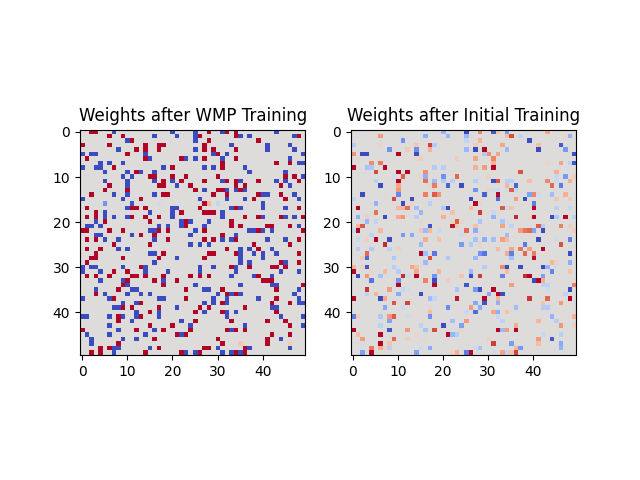

In [ ]:
wmp_decoder = Decoder(N=N, N_out=2, reduced_dim=N_COMPONENTS, W=perturbations["within_manifold_perturbation"])
network.W = w1.copy() # reset to trained weights
wmp_loss = network.train(
    N_TRIALS_RELEARN,
    stim,
    PULSE_LENGTH,
    wmp_decoder,
    target_traj,
    lr=LEARNING_RATE
)
w_wmp = network.W.copy()  # weights after within-manifold perturbation training
fig, axs = plt.subplots(1, 2)
axs[0].imshow(w_wmp, cmap='coolwarm', vmin=-1, vmax=1)
axs[0].set_title("Weights after WMP Training")
axs[1].imshow(w1, cmap='coolwarm', vmin=-1, vmax=1)
axs[1].set_title("Weights after Initial Training")    

Text(0, 0.5, 'Loss')

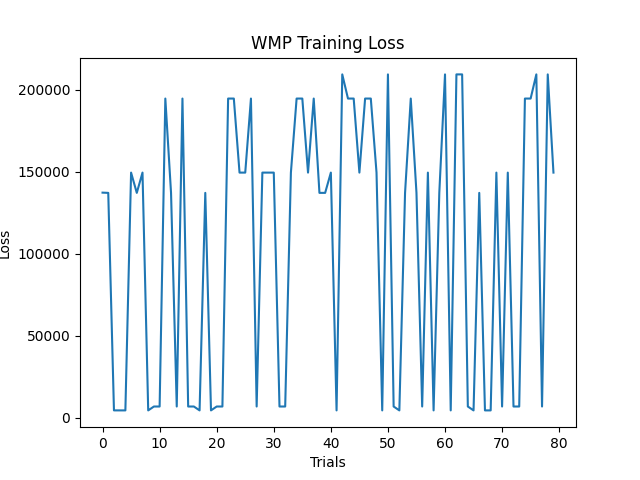

In [ ]:
# plot loss trajectory
fig, ax = plt.subplots(1, 1)
ax.set_title("WMP Training Loss")
ax.plot(wmp_loss, label="WMP Training Loss")
ax.set_xlabel("Trials")
ax.set_ylabel("Loss")

### Outside Manifold Perturbations

In [ ]:
omp_decoder = Decoder(N=N, N_out=2, reduced_dim=N_COMPONENTS, W=perturbations["outside_manifold_perturbation"])
network.W = w1.copy()  # reset to trained weights
omp_loss = network.train(
    N_TRIALS_RELEARN,
    stim,
    PULSE_LENGTH,
    omp_decoder,
    target_traj,
    lr=LEARNING_RATE
)
w_omp = network.W.copy()  # weights after outside-manifold perturbation training


Text(0.5, 1.0, 'Weights after Initial Training')

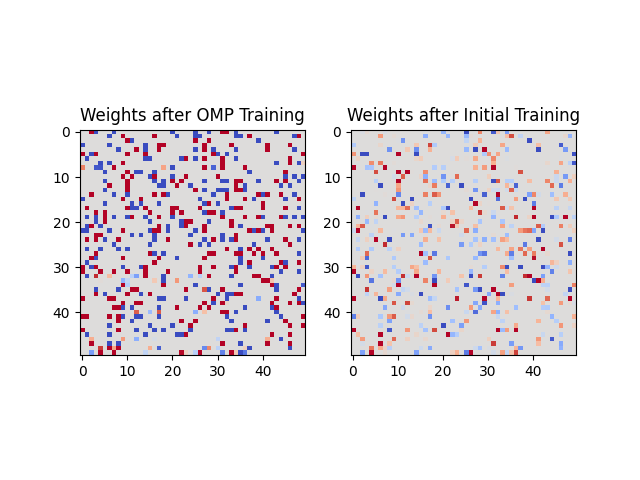

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(w_omp, cmap='coolwarm', vmin=-1, vmax=1)
axs[0].set_title("Weights after OMP Training")
axs[1].imshow(w1, cmap='coolwarm', vmin=-1, vmax=1)
axs[1].set_title("Weights after Initial Training")

Text(0, 0.5, 'Loss')

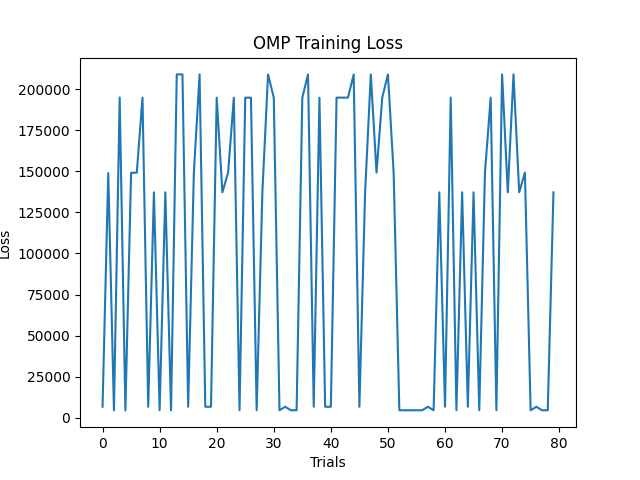

In [ ]:
# plot lost trajectories
fig, ax = plt.subplots(1, 1)
ax.set_title("OMP Training Loss")
ax.plot(omp_loss, label="OMP Training Loss")
ax.set_xlabel("Trials")
ax.set_ylabel("Loss")

In [ ]:
np.outer([92, 60, 100], [80, 30, 70]) / 2

array([[3680., 1380., 3220.],
       [2400.,  900., 2100.],
       [4000., 1500., 3500.]])